In [1]:
using DataFrames
using Dates
using CSV
using Plots
using Statistics

In [11]:
"""
    read_ratacad_csv(path::AbstractString; force_string_read=true) -> DataFrame

Reads RATACAD-style CSVs where the true header row is stored as the first data row.

- Promotes row 1 to column names (sanitized + unique).
- Drops that row from the data.

If `force_string_read=true`, reads all columns as String on the first pass to
avoid type inference problems before the header promotion.
"""
function read_ratacad_csv(path::AbstractString; force_string_read::Bool=true)
    df = force_string_read ?
        CSV.read(path, DataFrame; types=String) :
        CSV.read(path, DataFrame)

    # Extract the "true header row" (row 1 of the parsed DF)
    hdr = Vector{String}(undef, ncol(df))
    for (j, v) in enumerate(eachcol(df))
        x = v[1]
        s = ismissing(x) ? "" : String(x)
        s = strip(s)
        hdr[j] = isempty(s) ? "Column$(j)" : s
    end

    # Make valid, unique Symbol names
    rename!(df, Symbol.(hdr); makeunique=true)

    # Drop the header row
    return df[2:end, :]
end

occ_df = read_ratacad_csv("../data/RATACAD_full_test.csv")

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\ryansenne\.julia\packages\CSV\XLcqT\src\file.jl:593


Row,#,"Date Time, GMT-04:00","Light (LGR S/N: 21175125, SEN S/N: 21175125, LBL: RATACAD 714F)","Occupancy (LGR S/N: 21175125, SEN S/N: 21175125, LBL: RATACAD 714F)",Internal Calibration (LGR S/N: 21175125),Host Connected (LGR S/N: 21175125),Stopped (LGR S/N: 21175125),End Of File (LGR S/N: 21175125)
,String,String,String?,String?,String?,String?,String?,String?
1,1,08/09/21 03:30:00 PM,1.00,0.00,Logged,missing,missing,missing
2,2,08/09/21 07:31:45 PM,0.00,missing,missing,missing,missing,missing
3,3,08/10/21 07:29:48 AM,1.00,missing,missing,missing,missing,missing
4,4,08/10/21 10:51:23 AM,missing,1.00,missing,missing,missing,missing
5,5,08/10/21 10:52:44 AM,missing,0.00,missing,missing,missing,missing
6,6,08/10/21 10:53:00 AM,missing,1.00,missing,missing,missing,missing
7,7,08/10/21 10:59:06 AM,missing,0.00,missing,missing,missing,missing
8,8,08/10/21 10:59:45 AM,missing,1.00,missing,missing,missing,missing
9,9,08/10/21 11:02:17 AM,missing,0.00,missing,missing,missing,missing


In [12]:
# Helper: robustly convert "1.00"/"0.00"/1/0/missing to Int 0/1; otherwise return missing
function to_occ01(x)
    if ismissing(x)
        return missing
    elseif x isa Real
        return Int(x != 0)
    else
        s = strip(String(x))
        isempty(s) && return missing
        v = tryparse(Float64, s)
        v === nothing && return missing
        return Int(v != 0.0)
    end
end

# Helper: robust DateTime parse (String or DateTime)
function to_dt(x; dt_format=DateFormat("mm/dd/yy I:MM:SS p"))
    x isa DateTime && return x
    s = strip(String(x))
    return DateTime(s, dt_format)
end

"""
    occupancy_events(df; dt_col, occ_col, dt_format)

Extract (dt, occ) events from an existing DataFrame where occ may be String?/missing.
Keeps only rows with a valid occupancy value.
"""
function occupancy_events(df::DataFrame;
                          dt_col::Symbol,
                          occ_col::Symbol,
                          dt_format::DateFormat = DateFormat("mm/dd/yy I:MM:SS p"))

    out = DataFrame(dt = DateTime[], occ = Int[])

    for i in 1:nrow(df)
        occ = to_occ01(df[i, occ_col])
        ismissing(occ) && continue
        dt = to_dt(df[i, dt_col]; dt_format=dt_format)
        push!(out, (dt=dt, occ=occ))
    end

    sort!(out, :dt)
    return out
end

function occupancy_fraction(events::DataFrame,
                            window_start::DateTime,
                            window_end::DateTime;
                            default_state::Int = 0)

    window_end <= window_start && error("window_end must be after window_start.")

    nrow(events) == 0 && return default_state == 1 ? 1.0 : 0.0

    # state at window_start = last known occupancy before start, else default
    state = default_state
    for i in 1:nrow(events)
        if events.dt[i] < window_start
            state = events.occ[i]
        else
            break
        end
    end

    t_prev = window_start
    occupied_seconds = 0.0

    for i in 1:nrow(events)
        t = events.dt[i]
        v = events.occ[i]

        t <= window_start && continue
        t >= window_end && break

        if state == 1
            occupied_seconds += Dates.value(t - t_prev) / 1000  # ms -> s
        end

        t_prev = t
        state = v
    end

    if state == 1
        occupied_seconds += Dates.value(window_end - t_prev) / 1000
    end

    total_seconds = Dates.value(window_end - window_start) / 1000
    return occupied_seconds / total_seconds
end

function daily_occupancy_prob(events::DataFrame; default_state::Int = 0)
    nrow(events) == 0 && return DataFrame(day=Date[], p_occupied=Float64[])

    first_day = Date(events.dt[1])
    last_day  = Date(events.dt[end])

    days = collect(first_day:last_day)
    probs = Float64[]

    for d in days
        ws = DateTime(d)
        we = DateTime(d + Day(1))
        push!(probs, occupancy_fraction(events, ws, we; default_state=default_state))
    end

    return DataFrame(day=days, p_occupied=probs)
end

daily_occupancy_prob (generic function with 1 method)

In [ ]:
seconds_in_day() = 24 * 60 * 60

# seconds since midnight
sec_since_midnight(dt::DateTime) = Dates.value(dt - DateTime(Date(dt))) ÷ 1000

# Convert a Dates.Period to whole seconds robustly
period_to_seconds(p::Period) = Int(Dates.value(Millisecond(p)) ÷ 1000)

function _accumulate_segment!(occ_seconds::Vector{Float64},
                              tot_seconds::Vector{Float64},
                              seg_start::DateTime,
                              seg_end::DateTime,
                              state::Int,
                              bin_seconds::Int)

    a = sec_since_midnight(seg_start)
    b = sec_since_midnight(seg_end)

    a = max(a, 0)
    b = min(b, seconds_in_day())
    b <= a && return

    first_bin = (a ÷ bin_seconds) + 1
    last_bin  = ((b - 1) ÷ bin_seconds) + 1

    for k in first_bin:last_bin
        bin_a = (k - 1) * bin_seconds
        bin_b = min(k * bin_seconds, seconds_in_day())

        overlap = max(0, min(b, bin_b) - max(a, bin_a))
        if overlap > 0
            tot_seconds[k] += overlap
            if state == 1
                occ_seconds[k] += overlap
            end
        end
    end
end

"""
    time_of_day_occupancy_profile(events; bin=Minute(5), default_state=0)

Compute occupancy probability by time-of-day across all days spanned by events.

Returns DataFrame:
- :tod_start  :: Time
- :p_occupied :: Float64
"""
function time_of_day_occupancy_profile(events::DataFrame;
                                       bin::Period = Minute(5),
                                       default_state::Int = 0)

    nrow(events) == 0 && return DataFrame(tod_start=Time[], p_occupied=Float64[])

    ev = sort(events, :dt)

    bin_seconds = period_to_seconds(bin)
    bin_seconds >= 1 || error("bin must be >= 1 second (got $(bin_seconds) seconds from bin=$bin).")

    nbins = cld(seconds_in_day(), bin_seconds)
    occ_seconds = zeros(Float64, nbins)
    tot_seconds = zeros(Float64, nbins)

    first_day = Date(ev.dt[1])
    last_day  = Date(ev.dt[end])

    # For efficiency: keep an index into ev as we move through days
    idx = 1

    for d in first_day:last_day
        day_start = DateTime(d)
        day_end   = day_start + Day(1)

        # state at midnight: last event before day_start, else default_state
        state = default_state
        while idx <= nrow(ev) && ev.dt[idx] < day_start
            state = ev.occ[idx]
            idx += 1
        end

        # Walk events within this day
        t_prev = day_start
        j = idx

        while j <= nrow(ev) && ev.dt[j] < day_end
            t = ev.dt[j]
            if t > t_prev
                _accumulate_segment!(occ_seconds, tot_seconds, t_prev, t, state, bin_seconds)
            end
            t_prev = t
            state = ev.occ[j]
            j += 1
        end

        # Tail to end of day
        if day_end > t_prev
            _accumulate_segment!(occ_seconds, tot_seconds, t_prev, day_end, state, bin_seconds)
        end
    end

    p = [tot_seconds[k] > 0 ? occ_seconds[k] / tot_seconds[k] : NaN for k in 1:nbins]
    tod = [Time(0) + Second((k-1)*bin_seconds) for k in 1:nbins]

    return DataFrame(tod_start=tod, p_occupied=p)
end

"""
    shift_profile_to_lights_on(profile; lights_on=Time(7,30))

Takes a time-of-day occupancy profile with columns:
- :tod_start :: Time
- :p_occupied :: Float64

Returns a new DataFrame with:
- :hours_since_lights_on :: Float64  in [0, 24)
- :p_occupied :: Float64

with the curve circularly shifted so lights_on is at 0.
"""
function shift_profile_to_lights_on(profile::DataFrame; lights_on::Time=Time(7,30))
    @assert :tod_start in names(profile) && :p_occupied in names(profile)

    # infer bin size in seconds from consecutive tod_start entries
    t = profile.tod_start
    length(t) >= 2 || error("Profile must have at least 2 bins to infer bin size.")
    bin_seconds = Int(Dates.value(Second(t[2] - t[1])))

    # compute index of the bin that starts at lights_on
    lights_on_seconds = Dates.value(Second(lights_on - Time(0)))
    shift_bins = Int(floor(lights_on_seconds / bin_seconds))

    n = nrow(profile)

    # circularly rotate rows so that lights_on bin is first
    idx = vcat((shift_bins+1):n, 1:shift_bins)
    rotated = profile[idx, :]

    # create x-axis as hours since lights on
    hours = ((0:(n-1)) .* bin_seconds) ./ 3600
    return DataFrame(hours_since_lights_on = hours, p_occupied = rotated.p_occupied)
end

function plot_profile_since_lights_on(profile_shifted::DataFrame; as=:bar)
    x = profile_shifted.hours_since_lights_on
    y = profile_shifted.p_occupied

    if as == :line
        plot(x, y,
             xlabel="Hours since lights-on (07:30 = 0)",
             ylabel="P(occupied)",
             title="Occupancy probability aligned to lights-on",
             legend=false,
             xlims=(0, 24))
    else
        bar(x, y,
            xlabel="Hours since lights-on (07:30 = 0)",
            ylabel="P(occupied)",
            title="Occupancy probability aligned to lights-on",
            legend=false,
            xlims=(0, 24))
    end
end

plot_profile_since_lights_on (generic function with 1 method)

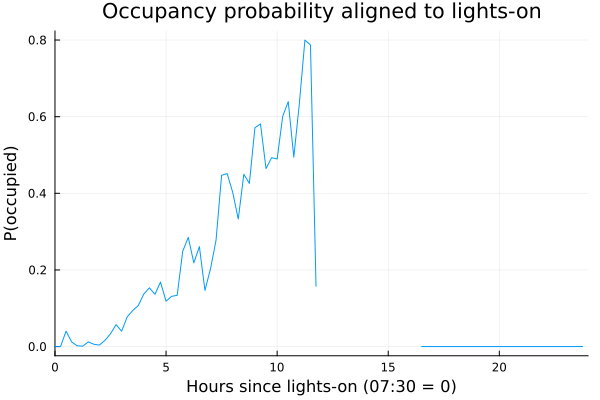

In [15]:
dt_col  = Symbol("Date Time, GMT-04:00")
occ_col = Symbol("Occupancy (LGR S/N: 21175125, SEN S/N: 21175125, LBL: RATACAD 714F)")

events = occupancy_events(occ_df; dt_col=dt_col, occ_col=occ_col)
daily  = daily_occupancy_prob(events; default_state=0)

profile = time_of_day_occupancy_profile(events; bin=Minute(15), default_state=0)

profile_shifted = shift_profile_to_lights_on(profile; lights_on=Time(7,30))

plot_profile_since_lights_on(profile_shifted; as=:line)   # histogram-like
